In [2]:
# Import necessary libraries for data handling and modeling

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load the transaction dataset

df = pd.read_excel(r"C:\Users\Administrator\Desktop\AUC\Customers_Transactions.xlsx")

# Display first 5 rows
df.head()

,EventID,EventType,ProductID,ProductName,Quantity,EventDateTime,UnitPrice,UserID
0,612890,Purchased,97393,DIWALI LANTERN WITH CARDBOARD,32,2019-12-01 07:45:00,624.80,25430
1,612890,Purchased,91668P,FLOWER POTS WITH FLOWER,32,2019-12-01 07:45:00,607.40,25430
2,612890,Purchased,91668W,RED COLORED LIGHTS,32,2019-12-01 07:45:00,607.40,25430
3,612890,Purchased,34386,PHOTO FRAME,68,2019-12-01 07:45:00,197.85,25430
4,612890,Purchased,33577,FUNNY HAT,44,2019-12-01 07:45:00,123.90,25430


In [4]:
# Check structure of dataset
df.info()

# Count of different event types
df['EventType'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417534 entries, 0 to 417533
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   EventID        417534 non-null  object        
 1   EventType      417534 non-null  object        
 2   ProductID      417534 non-null  object        
 3   ProductName    417534 non-null  object        
 4   Quantity       417534 non-null  int64         
 5   EventDateTime  417534 non-null  datetime64[ns]
 6   UnitPrice      417534 non-null  float64       
 7   UserID         417534 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 25.5+ MB


EventType
Purchased    407695
Returned       9839
Name: count, dtype: int64

In [5]:
# Create user-level features
features = df.groupby('UserID').agg(
    Total_Events=('EventID','count'),
    Views=('EventType', lambda x: (x=='Viewed').sum()),
    AddToCart=('EventType', lambda x: (x=='AddToCart').sum()),
    Purchases=('EventType', lambda x: (x=='Purchased').sum()),
    Total_Spend=('UnitPrice', lambda x: df.loc[x.index][df.loc[x.index,'EventType']=='Purchased']['UnitPrice'].sum())
).reset_index()

features.head()

,UserID,Total_Events,Views,AddToCart,Purchases,Total_Spend
0,24691,46,0,0,33,18568.27
1,24692,71,0,0,71,15262.30
2,24693,20,0,0,20,1554.93
3,24694,107,0,0,102,77864.88
4,24696,21,0,0,21,4626.17


In [6]:
features['Purchased_Flag'] = features['Purchases'].apply(lambda x: 1 if x > 0 else 0)

features.head()

,UserID,Total_Events,Views,AddToCart,Purchases,Total_Spend,Purchased_Flag
0,24691,46,0,0,33,18568.27,1
1,24692,71,0,0,71,15262.30,1
2,24693,20,0,0,20,1554.93,1
3,24694,107,0,0,102,77864.88,1
4,24696,21,0,0,21,4626.17,1


In [7]:
X = features[['Total_Events','Views','AddToCart','Total_Spend']]
y = features['Purchased_Flag']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
y_pred = model.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[ 12   0]
 [  0 865]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00       865

    accuracy                           1.00       877
   macro avg       1.00      1.00      1.00       877
weighted avg       1.00      1.00      1.00       877



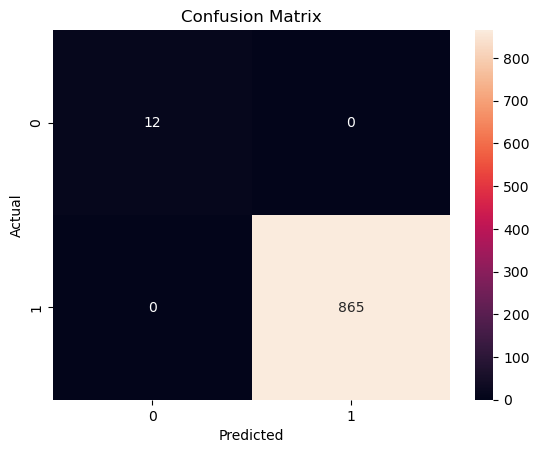

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
# Understanding which features impact prediction the most

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,Total_Spend,0.617423
0,Total_Events,0.059854
1,Views,0.000000
2,AddToCart,0.000000


In [14]:
# Instead of just 0/1 prediction, model also gives probability

y_prob = model.predict_proba(X_test)[:,1]

# Show first 10 probabilities
y_prob[:10]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

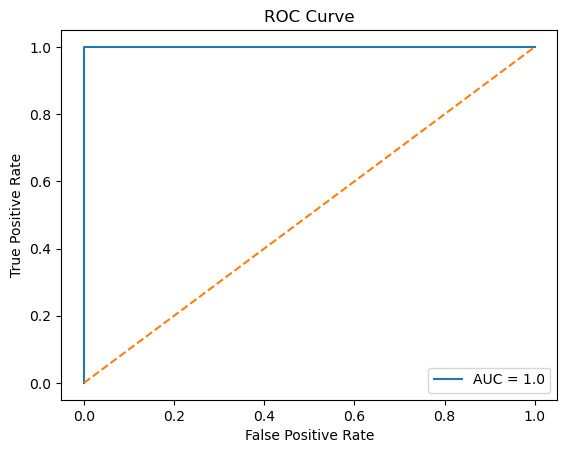

In [15]:
# ROC Curve shows model performance visually

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [16]:
user_product = df[df['EventType'] == 'Purchased'].pivot_table(
    index='UserID',
    columns='ProductName',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_product)
similarity_df = pd.DataFrame(similarity, index=user_product.index, columns=user_product.index)

In [18]:
def recommend_products(user_id):
    similar_users = similarity_df[user_id].sort_values(ascending=False)[1:6]
    
    similar_users_products = user_product.loc[similar_users.index]
    
    recommendations = similar_users_products.sum().sort_values(ascending=False)
    
    return recommendations.head(5)